In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

data = pd.read_csv("/content/gdrive/MyDrive/ia/RT_IOT2022")
print(data.shape)
data.head()

Mounted at /content/gdrive
(123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [3]:
print(data.columns.tolist())
data.info()

['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_iat.to

In [4]:
data = data.drop_duplicates()
data = data.drop("Unnamed: 0", axis=1)

for col in data.select_dtypes(include="object").columns:
    data[col] = pd.Categorical(data[col]).codes

print("Valores nulos:", data.isnull().sum().sum())
print(data.shape)

Valores nulos: 0
(123117, 84)


In [5]:
X = data.drop("Attack_type", axis=1).values
y = data["Attack_type"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (123117, 83)
y shape: (123117,)


In [6]:
y_binario = (y > 0).astype(int)
print("Distribución de clases:")
print(pd.Series(y_binario).value_counts())

Distribución de clases:
1    115367
0      7750
Name: count, dtype: int64


In [7]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)
print("Normalización completada")

Normalización completada


In [8]:
np.random.seed(42)
m = len(y_binario)
indices = np.random.permutation(m)

corte = int(0.8 * m)
train_idx = indices[:corte]
test_idx = indices[corte:]

X_train = X_norm[train_idx]
y_train = y_binario[train_idx]

X_test = X_norm[test_idx]
y_test = y_binario[test_idx]

print(f"Entrenamiento: {X_train.shape[0]} ejemplos ({X_train.shape[0]/m*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]} ejemplos ({X_test.shape[0]/m*100:.0f}%)")

Entrenamiento: 98493 ejemplos (80%)
Prueba:        24624 ejemplos (20%)


In [9]:
X_train_final = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
X_test_final = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

X_train_final shape: (98493, 84)
X_test_final shape: (24624, 84)


In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [11]:
def computeCost(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (-1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    return J

In [12]:
def gradientDescent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    for i in range(iterations):
        h = sigmoid(X.dot(theta))
        errors = h - y
        theta = theta - (alpha / m) * (X.T.dot(errors))
        cost_history.append(computeCost(X, y, theta))
    return theta, cost_history

In [13]:
theta = np.zeros(X_train_final.shape[1])
alpha = 0.01
iterations = 1000

theta, cost_history = gradientDescent(X_train_final, y_train, theta, alpha, iterations)

print("Costo final entrenamiento:", computeCost(X_train_final, y_train, theta))

Costo final entrenamiento: 0.16938460472985808


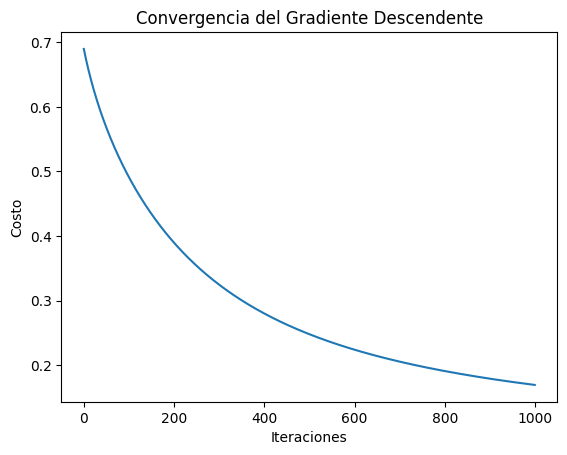

In [14]:
plt.plot(cost_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Convergencia del Gradiente Descendente")
plt.show()

In [15]:
def predict(X, theta):
    return (sigmoid(X.dot(theta)) >= 0.5).astype(int)

pred_train = predict(X_train_final, theta)
pred_test = predict(X_test_final, theta)

precision_train = np.mean(pred_train == y_train) * 100
precision_test = np.mean(pred_test == y_test) * 100

print(f"Precisión en entrenamiento (80%): {precision_train:.2f}%")
print(f"Precisión en prueba        (20%): {precision_test:.2f}%")

Precisión en entrenamiento (80%): 94.15%
Precisión en prueba        (20%): 93.90%


In [16]:
np.random.seed(42)
indices_pred = np.random.choice(len(y_test), 100, replace=False)

X_pred = X_test_final[indices_pred]
y_real = y_test[indices_pred]
predicciones = predict(X_pred, theta)

precision_100 = np.mean(predicciones == y_real) * 100
print(f"Precisión en 100 predicciones de prueba: {precision_100:.2f}%")

print("\nMuestra de 10 predicciones:")
print(f"{'#':<5}{'Real':<10}{'Predicción':<12}{'Resultado'}")
print("-" * 40)
for i in range(10):
    resultado = "✓ Correcto" if predicciones[i] == y_real[i] else "✗ Error"
    print(f"{i+1:<5}{y_real[i]:<10}{predicciones[i]:<12}{resultado}")

Precisión en 100 predicciones de prueba: 95.00%

Muestra de 10 predicciones:
#    Real      Predicción  Resultado
----------------------------------------
1    1         1           ✓ Correcto
2    1         1           ✓ Correcto
3    1         1           ✓ Correcto
4    1         1           ✓ Correcto
5    0         0           ✓ Correcto
6    1         1           ✓ Correcto
7    1         1           ✓ Correcto
8    1         1           ✓ Correcto
9    1         1           ✓ Correcto
10   1         1           ✓ Correcto


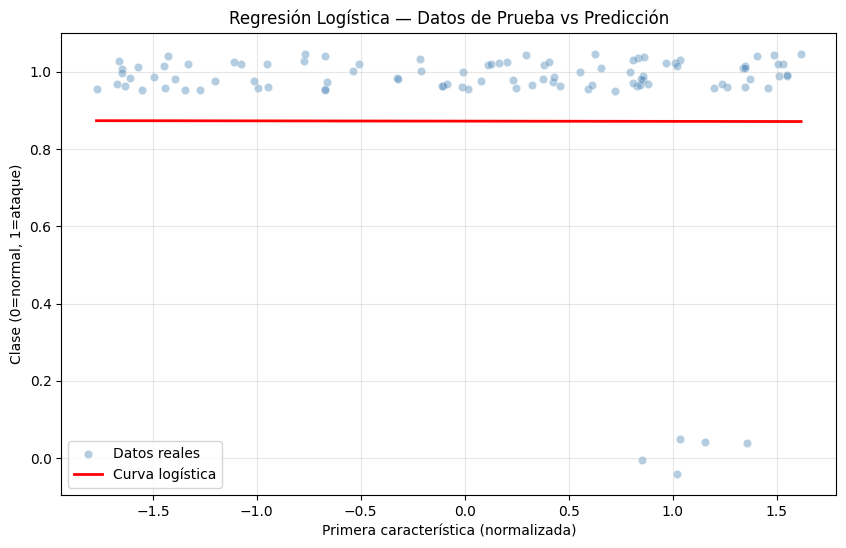

In [17]:
ruido = np.random.uniform(-0.05, 0.05, size=100)
x_plot = X_test[indices_pred, 0]
x_linea = np.linspace(x_plot.min(), x_plot.max(), 100)

plt.figure(figsize=(10, 6))
plt.scatter(x_plot, y_real + ruido, color="steelblue", alpha=0.4,
            edgecolors="white", linewidths=0.5, label="Datos reales")
plt.plot(x_linea, sigmoid(theta[0] + theta[1] * x_linea),
         color="red", linewidth=2, label="Curva logística")
plt.xlabel("Primera característica (normalizada)")
plt.ylabel("Clase (0=normal, 1=ataque)")
plt.title("Regresión Logística — Datos de Prueba vs Predicción")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()